In [381]:
# Imports and global vars
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('ggplot')
pd.set_option('display.max_columns', 30) # dataset have 21 columns

cwd = Path.cwd()
project_dir = cwd.parent
data_dir = project_dir / 'data'

In [382]:
raw_data = (data_dir / 'raw' / 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
# print(raw_data.is_file())
df = pd.read_csv(raw_data)

In [383]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [384]:
row_count, column_count = df.shape
print(f"There are {row_count} rows and {column_count} columns in this dataset")

There are 7043 rows and 21 columns in this dataset


In [385]:
# Guiding Questions for EDA
# 1. What does one row represent? # Answer : Each row represents one customer account. The row includes demographic attributes, subscribed services, account/contract information, billing charges, and the churn label.
# 2. What is the target column? # Answer : the 'Churn' column.
# 3. Is the target balanced or imbalanced? # Answer : The data is imbalanced - 73.4% are not Churn while 26.6% are (in numbers 5174 and 1869).
# 4. Which columns are numeric, categorical, or IDs? # Answer: 
#       customerID is an ID column.
#       tenure, MonthlyCharges are numeric columns.
#       TotalCharges dtype is str but should be numeric. this column stores blank values (' ') and requires cleaning.
#       SeniorCitizen stores integer values but it's categorical.
#       Rest of the columns are categorical.
# 5. Are there missing values or strange data types? # Answer : TotalCharges column stores blank values (' ') and requires investigation why.
# 6. Is there any feature that might not be available at prediction time? # Answer : 
# Churn is the target label and must be excluded during training and prediction. 
# customerID column is an identifier and should be excluded from modeling as well.
# All other columns are assumed to be avialable during prediction

In [386]:
# Answer for Q3 - is the targget value balanced ?
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [387]:
# Answer for Q4 - numeric vs categorical columns analysis
dtypes = df.dtypes
# print(f'All the dtypes in data frame :\n\n{dtypes}')
print(f"All the columns with non 'str' dtype :\n{dtypes[('str' != dtypes)]}")
print(f"All the columns with 'str' dtype :\n{dtypes[('str' == dtypes)]}")


print(f'\n\nSeniorCitizen have the following values\n{df['SeniorCitizen'].value_counts()}')
print(f'\n\nTotalCharges have the following values\n{df['TotalCharges'].value_counts()}')
print(f'\nMeaning : SeniorCitizen is actually categorical and TotalCharges is numeric')

numeric_columns  = dtypes['str' != dtypes].index.to_list()
category_columns = dtypes['str' == dtypes].index.to_list()

numeric_columns.remove('SeniorCitizen')
numeric_columns.append('TotalCharges')

category_columns.remove('TotalCharges')
category_columns.append('SeniorCitizen')


print(f'\nnumeric columns are {numeric_columns}')
print(f'\ncategorical columns are {category_columns}')

All the columns with non 'str' dtype :
SeniorCitizen       int64
tenure              int64
MonthlyCharges    float64
dtype: object
All the columns with 'str' dtype :
customerID          str
gender              str
Partner             str
Dependents          str
PhoneService        str
MultipleLines       str
InternetService     str
OnlineSecurity      str
OnlineBackup        str
DeviceProtection    str
TechSupport         str
StreamingTV         str
StreamingMovies     str
Contract            str
PaperlessBilling    str
PaymentMethod       str
TotalCharges        str
Churn               str
dtype: object


SeniorCitizen have the following values
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


TotalCharges have the following values
TotalCharges
20.2      11
          11
19.75      9
19.9       8
20.05      8
          ..
1990.5     1
7362.9     1
346.45     1
306.6      1
6844.5     1
Name: count, Length: 6531, dtype: int64

Meaning : SeniorCitizen is actually categorical 

In [388]:
# Answer Q5 - missing values, duplicates and strange values

# duplicated rows and or duplicated data for customers
print(df.duplicated().any())
print(df['customerID'].duplicated().any())

False
False


In [389]:
# Missing values
print(df.isna().any(axis=0)) # nan values check
print(df.eq(' ').sum())      # blank values check 

customerID          False
gender              False
SeniorCitizen       False
Partner             False
Dependents          False
tenure              False
PhoneService        False
MultipleLines       False
InternetService     False
OnlineSecurity      False
OnlineBackup        False
DeviceProtection    False
TechSupport         False
StreamingTV         False
StreamingMovies     False
Contract            False
PaperlessBilling    False
PaymentMethod       False
MonthlyCharges      False
TotalCharges        False
Churn               False
dtype: bool
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
Total

In [390]:
# missing values at TotalCharges investigation
# Since MonthlyCharges * tenure =~ TotalCharges
# TotalCharges == 0 --->  tenure == 0 ?
rows_with_blan_tc = df.eq(' ').any(axis=1)
print(df.loc[rows_with_blan_tc, 'tenure'])

488     0
753     0
936     0
1082    0
1340    0
3331    0
3826    0
4380    0
5218    0
6670    0
6754    0
Name: tenure, dtype: int64


In [391]:
## TotalCharges Investigation
# - There are 11 blank values in the TotalCharges. There are no any missing values except those in this dataset.
# - Tenure is 0 For all rows with blank values at TotalCharges.
# - TotalCharges are missing in those instances becuase the tenure is less than a month and no charges were made.
# cleaning options:
#   - Setting TotalCharges to match MonthlyCharges
#   - Convert all blank values to nan and impute them later on
#   - Delete rows entirely
#   - TotalCharges = 0
# - Since MonthlyCharges * tenure ~= TotalCharges (tc is the accumlated charges for a customer for the entire subscription period),
#   0 tenure ---> TotalCharges = 0.
#   Cleaning the data would require to cast entire tc column as float with missing values as 0.

In [392]:
df.head(n=10)

# Data Dictionary 
# | Column | Meaning | Raw dtype | ML role | Notes |
# |---|---|---:|---|---|
# | customerID | Unique customer identifier   | str | exclude | ID column, not useful for generalization |
# | gender | Customer gender (Male or Female) | str | binary categorical | need to inspect |
# | SeniorCitizen | Whether customer is senior citizen | int | binary categorical | Stored as 0/1 |
# | Partner | Whether the customer has a partner or not (Yes, No) | str | binary categorical | need to inspect |
# | Dependents | Whether the customer has dependents or not (Yes, No) | str | binary categorical | need to inspect |
# | tenure | Number of months the customer has stayed with the company | int | numeric feature | Important customer lifecycle variable |
# | PhoneService | Whether the customer has a phone service or not (Yes, No) | str | binary categorical | need to inspect |
# | MultipleLines | Whether the customer has multiple lines or not (Yes, No, No phone service) | str | non binary categorical | need to inspect |
# | InternetService | Customer’s internet service provider (DSL, Fiber optic, No) | str | non binary categorical | need to inspect |
# | OnlineSecurity | Whether the customer has online security or not (Yes, No, No internet service) | str | non binary categorical | need to inspect |
# | OnlineBackup | Whether the customer has online backup or not (Yes, No, No internet service) | str | non binary categorical | need to inspect |
# | DeviceProtection | Whether the customer has device protection or not (Yes, No, No internet service) | str | non binary categorical | need to inspect |
# | TechSupport | Whether the customer has tech support or not (Yes, No, No internet service) | str | non binary categorical | need to inspect |
# | StreamingTV | Whether the customer has streaming TV or not (Yes, No, No internet service) | str | non binary categorical | need to inspect |
# | StreamingMovies | Whether the customer has streaming movies or not (Yes, No, No internet service) | str | non binary categorical | need to inspect |
# | Contract | The contract term of the customer (Month-to-month, One year, Two year) | str | non binary categorical | need to inspect |
# | PaperlessBilling | Whether the customer has paperless billing or not (Yes, No) | str | binary categorical | need to inspect |
# | PaymentMethod | The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card) | str | non binary categorical | need to inspect |
# | MonthlyCharges | Monthly bill amount | float | numeric feature | Numeric |
# | TotalCharges | Total accumulated charges | object | numeric feature | Needs conversion; blanks with tenure=0 become 0 |
# | Churn | Whether customer churned | str | target | Binary target: Yes/No |



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [438]:
# EDA summary: 
######################
# Thoroughly inspected columns : tenure, MonthlyCharges, TotalCharges, Contract, PaymentMethod, InternetService & TechSupport

# Tenure : 
# Churn rate is highest for low tenure groups and will decrease monotonically for increasing tenure.  Churn rate decreases from about 53% in the 0–6 month group to about 10% in the 49–72 month group.

# MonthlyCharges :
# churn rate is small for low mc ranges, really high (36%-40%) for several mid-high (70-108) mc ranges and for the rest is about 25%. About 69% of churned customers fall into the high risk range.

# TotalCharges :
# Churn rate is highest for low total charges groups and would monotonically decrease as total charges increase except a single spike for a mid-high group.

### Numeric features relationship:
# `TotalCharges` is strongly related to `tenure × MonthlyCharges`, which is expected because it represents accumulated customer charges over time. An exploratory `pred_tc = tenure × MonthlyCharges` feature shows an almost linear relationship with `TotalCharges`.
# correlation map shows high correlation between tenure and tc while mid mc have mid correlation to tc and low correlation to tenure.

# Contract :
# `Month-to-month` customers are both higher-risk and represent the majority of churn cases, accounting for about 88% of churned customers. 70% of the mtm customers are in low tenure groups (24 months or less)

# PaymentMethod : 
# `Electronic check` is the highet risk group and the biggest group within the general and churned populations. Overlapping with tenure and contract type is observeed.

# InternetService :
# `Fiber optic` customers have a much higher churn rate than `DSL` customers or customers with no internet service. A cross-check with `MonthlyCharges` shows that `Fiber optic` customers are heavily concentrated in higher monthly charge bins, while customers with no internet service are concentrated in the lowest monthly charge bin.

# TechSupport :
# About 50% of customers don't have tech support. Churn rate is highest for customers without tech support (41.6%) and really low for customers with tech support (15.2%).

# Online add-ons (Security, Backup):
# Customers without online add-ons shown high churn rates :
# OnlineSecurity :  without 41.8%, with 14.6%.
# OnlineBackup   :  without 39.9%, with 21.5%.

# DeviceProtection :
# Customers without DeviceProtection have higher churn, about 39.1%, compared with customers with DeviceProtection, about 22.5%. This follows the same general pattern as other internet add-on services.

# Streaming add-ons (TV & Movies) :
# Customers with or without streaming add-ons shown similarly high churn rates:
# StreamingTV :     without 33.5%, with 30.1%.
# StreamingMovies : without 33.7%, with 29.9%.

# PaperlessBilling :
# Customers with PaperlessBilling have much higher churn, about 33.6%, compared with customers without PaperlessBilling, about 16.3%. This may overlap with payment method, contract type, and customer segment.
# An intresting observation after corss checking with SeniorCitizen. given a senior citizen status, paper less biling shown churn rate close to the general population (25% for non senior and 75% for senior).

# SeniorCitizen : 
# Senior citizens have a much higher churn rate, about 41.7%, compared with non-senior customers, about 23.6%. Cross-checks suggest this is not mainly explained by tenure, but senior citizens are more concentrated in high-risk monthly charge ranges and show payment/billing patterns closer to the churned population.

# Partner, Dependents & single engineered feature :
# Customers without a partner or dependents have higher churn rates, about 33.0% and 31.3% compared with customers with a partner or dependent, about 19.7% and 15.5% respectively.
# A derived `single` feature, defined as customers with neither partner nor dependents, shows higher churn: about 34.2% for 'single' customers compared with about 19.8%.

# Gender :
# Male and female customers have shown similar churn rate to the general population.

# PhoneService & MultipleLines :
# Customers with or without these services shown similar churn rate to the general population.

# For more information see matching cells below.

In [394]:
# Auxiliry functions

def col_by_col(df, rows, cols, rows_bins=None, cols_bins=None, rows_labels=None, cols_labels=None):
    df = df.copy()
    rows_numeric = df.dtypes[rows] != 'str'
    cols_numeric = df.dtypes[cols] != 'str'
    
    # group by rows category
    rows_grp_by = pd.cut(df[rows], bins=rows_bins, labels=rows_labels) if rows_numeric else df[rows]
    rows_grp = df.groupby(rows_grp_by)
    
    # group new row category grouped df with cols category.final columns would by col category values & value counts.
    df = rows_grp[cols].value_counts() \
            .sort_index(level=0, ascending=True) \
            .reset_index(-1)
        
    # group new row category grouped df by rows and cols. final df rows would be rows_bins and columns would be cols_bins.
    cols_grp_by = pd.cut(df[cols], bins=cols_bins) if cols_numeric else df[cols]
    col_by_col_df = df['count'].groupby([rows, cols_grp_by]) \
                                .sum() \
                                .unstack() \
    
    # adding new 'All' column as the first column for analyzing general row category distribution
    # print(col_by_col_df)
    col_by_col_df['All'] = col_by_col_df.sum(axis=1)
    cols = ['All'] + [col for col in col_by_col_df.columns if col != 'All']
    col_by_col_df = col_by_col_df[cols]
    
    # changing rows and columns to display labels : rows_labels & cols_labels
    if rows_labels:
        col_by_col_df = col_by_col_df.set_axis(rows_labels, axis=0)
    
    if cols_labels:
        col_by_col_df = col_by_col_df.set_axis(cols_labels, axis=1)
        
        
    return col_by_col_df

    
def churn_rate(col_by_churn_df, title=None, plot=True):
    churn_by_col = col_by_churn_df.T
    
    cr = churn_by_col.loc['Churned'] / churn_by_col.loc['All']
    cr.name = "ChurnRate"
        
    if plot : 
        ax = cr.plot(kind='bar',
                     figsize=(10, 6),
                     ylabel='Churn Rate',
                     title=title)
    return cr
    
    
def make_bins(data, bins=None,) : 
    _, new_bins = np.histogram(data, bins=bins)
    new_bins[0] = new_bins[0] - 1 # include far-most left value.
    return new_bins



In [395]:
# EDA 

# filling all missing tc with 0's as explained earlier so I can preform EDA
clean_df = df.copy()
clean_df['TotalCharges']  = pd.to_numeric(clean_df['TotalCharges'], errors='coerce')
clean_df.fillna(0, inplace=True)

# casting SeniorCitizen to str
clean_df = clean_df.astype({"SeniorCitizen":"str"})

,All,NotChurned,Churned,ChurnRate
0-6 Months,0.210280,0.134712,0.419476,0.529372
7-12 Months,0.100099,0.087360,0.135367,0.358865
13-24 Months,0.145393,0.141090,0.157303,0.287109
25-36 Months,0.118131,0.126015,0.096308,0.216346
37-48 Months,0.108193,0.119250,0.077582,0.190289
49-72 Months,0.317904,0.391573,0.113965,0.095132


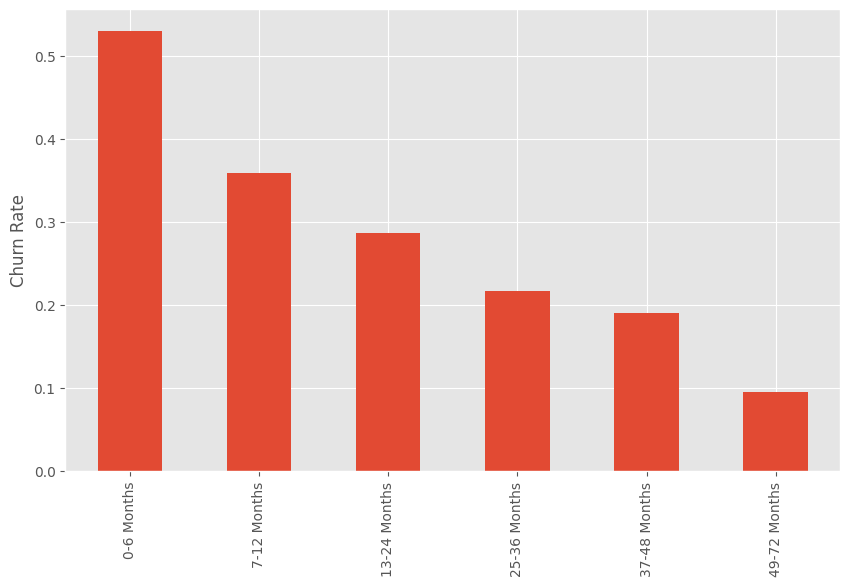

In [396]:
# tenure
# -----------------------------
# tenure distribution
rows = 'tenure'
cols = 'Churn'
tenure_bin_boundaries = [0, 6, 12, 24, 36, 48, clean_df['tenure'].max()]
tenure_bins = make_bins(clean_df['tenure'], tenure_bin_boundaries)

tenure_labels = [f"{tenure_bins[i] + 1}-{tenure_bins[i+1]} Months" for i in range(len(tenure_bins) - 1)]
cols_labels = ['All', 'NotChurned', 'Churned']

tenure_by_churn_df = col_by_col(clean_df, rows=rows, cols=cols, rows_bins=tenure_bins, rows_labels=tenure_labels, cols_labels=cols_labels)

tenure_composition_df = tenure_by_churn_df.div(
    tenure_by_churn_df.sum(axis=0), 
    axis=1
)

churn_rate_df = churn_rate(tenure_by_churn_df, 
                        plot=True)

info_table = pd.concat([tenure_composition_df, churn_rate_df], axis=1)

info_table

<function matplotlib.pyplot.show(close=None, block=None)>

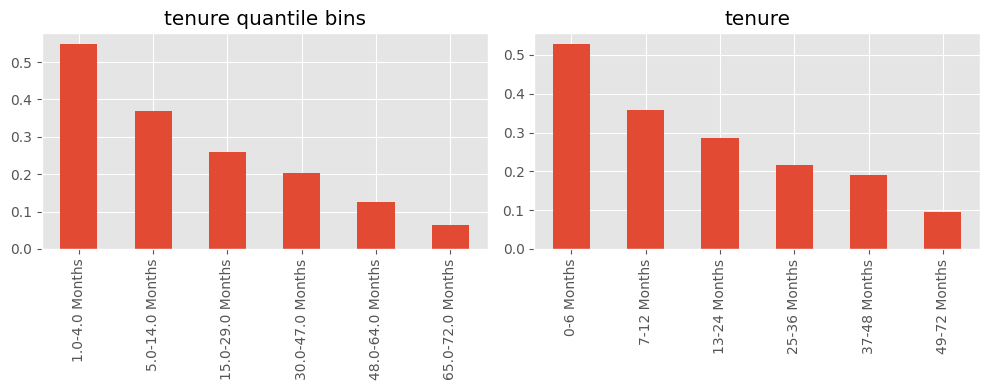

In [397]:
# quantile check of previous churn trend
tenure_quant = clean_df.copy()
q_bins = 6

tenure_quant['tenure'], tenure_quant_bins = pd.qcut(
    tenure_quant["tenure"],
    q=q_bins,
    retbins=True
)
tenure_quant_labels = [f"{tenure_quant_bins[i] + 1}-{tenure_quant_bins[i+1]} Months" for i in range(len(tenure_quant_bins) - 1)]
tenure_quant_analysis = (
    tenure_quant.groupby("tenure", observed=True)
      .agg(
          All=("Churn", "size"),
          Churned=("Churn", lambda x: (x == "Yes").sum()),
          NotChurned=("Churn", lambda x: (x == "No").sum()),
          ChurnRate=("Churn", lambda x: (x == "Yes").mean())
      )
)

tenure_quant_analysis.index = tenure_quant_labels

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
tenure_quant_analysis["ChurnRate"].plot(kind="bar", ax=axes[0], title="tenure quantile bins")
info_table['ChurnRate'].plot(kind="bar", ax=axes[1], title="tenure")

fig.tight_layout()
plt.show


In [398]:
## Tenure Notes:

### Question
# How does churn rate change as tenure increases?

### Hypothesis
# Lower-tenure customers are expected to churn more often because they may have lower attachment to the company.

### Evidence
# - Largest customer groups: 49–72 months and 0–6 months.
# - About 42% of churned customers are in the 0–6 month group.
# - About 71% of churned customers have tenure of 24 months or less.
# - Churn rate decreases from about 53% in the 0–6 month group to about 10% in the 49–72 month group.
# - The 13–24 month group is also worth noting because it has a medium churn rate and a meaningful customer share.

### Conclusion
# The hypothesis is supported. Early-tenure customers are both higher-risk and represent a large share of churn cases.

### Quantile-bin check
# A quantile-bin check shows the same decreasing pattern: churn rate is highest in the lowest-tenure groups and lowest in the highest-tenure groups.

,All,NotChurned,Churned,ChurnRate
MonthlyCharges,,,,
"(17.25, 28.3]",0.228028,0.281794,0.079187,0.092154
"(28.3, 38.35]",0.027119,0.025899,0.030498,0.298429
"(38.35, 48.4]",0.051825,0.047545,0.063670,0.326027
"(48.4, 58.45]",0.090870,0.094318,0.081327,0.237500
"(58.45, 68.5]",0.067301,0.081175,0.028892,0.113924
"(68.5, 78.55]",0.126793,0.105141,0.186731,0.390817
"(78.55, 88.6]",0.135312,0.115578,0.189941,0.372508
"(88.6, 98.65]",0.123953,0.106881,0.171215,0.366552
"(98.65, 108.7]",0.107057,0.093158,0.145532,0.360743


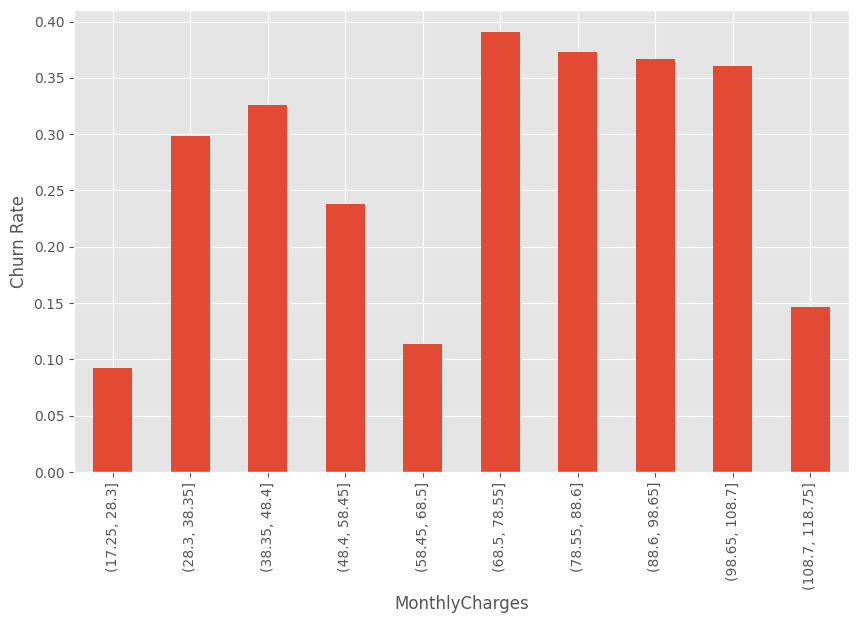

In [399]:
# MonthlyCharges
# -----------------------------
num_of_bins = 10
mc_bins = make_bins(clean_df['MonthlyCharges'], bins=num_of_bins)

rows = 'MonthlyCharges'
cols = 'Churn'
churn_labels = ['All', 'NotChurned', 'Churned']


mc_by_churn_df = col_by_col(clean_df, rows=rows, cols=cols, rows_bins=mc_bins, cols_labels=churn_labels)

mc_composition_df = mc_by_churn_df.div(
    mc_by_churn_df.sum(axis=0), 
    axis=1
)
churn_rate_df = churn_rate(mc_by_churn_df, 
                        plot=True)

info_table = pd.concat([mc_composition_df, churn_rate_df], axis=1)
info_table

,All,Churned,NotChurned,ChurnRate
MonthlyCharges_quantile_bin,,,,
"(18.249, 20.05]",717,61,656,0.085077
"(20.05, 25.05]",703,69,634,0.098151
"(25.05, 45.85]",695,177,518,0.254676
"(45.85, 58.83]",702,172,530,0.245014
"(58.83, 70.35]",711,153,558,0.215190
"(70.35, 79.1]",700,267,433,0.381429
"(79.1, 85.5]",705,267,438,0.378723
"(85.5, 94.25]",702,241,461,0.343305
"(94.25, 102.6]",704,288,416,0.409091


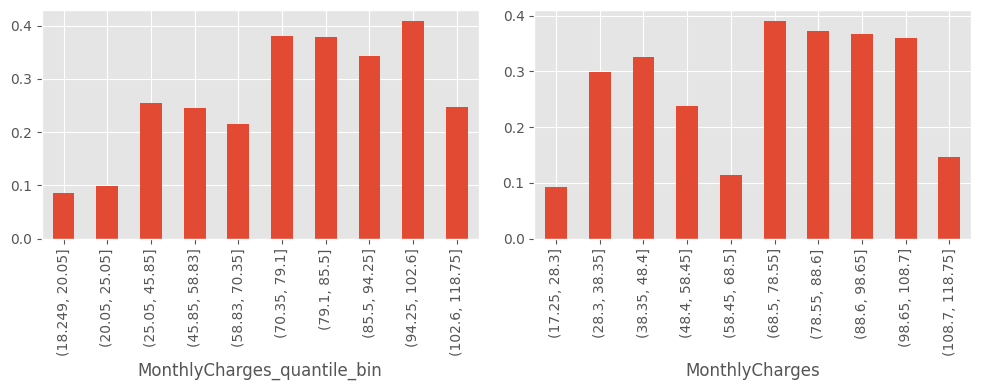

In [400]:
# quantile check of previous churn trend
q_bins = num_of_bins

mc_quant_analysis = clean_df.copy()

mc_quant_analysis["MonthlyCharges_quantile_bin"] = pd.qcut(
    mc_quant_analysis["MonthlyCharges"],
    q=q_bins
)

mc_quant_analysis_summary = (
    mc_quant_analysis.groupby("MonthlyCharges_quantile_bin", observed=True)
      .agg(
          All=("Churn", "size"),
          Churned=("Churn", lambda x: (x == "Yes").sum()),
          NotChurned=("Churn", lambda x: (x == "No").sum()),
          ChurnRate=("Churn", lambda x: (x == "Yes").mean())
      )
)


fig, axes = plt.subplots(1, 2, figsize=(10, 4))
mc_quant_analysis_summary["ChurnRate"].plot(kind="bar", ax=axes[0])
info_table['ChurnRate'].plot(kind="bar", ax=axes[1])

fig.tight_layout()
plt.show

mc_quant_analysis_summary

In [401]:
## MonthlyCharges Notes

### Question
# Does churn rate vary by monthly charge level?

### Hypothesis
# Customers with higher monthly charges may churn more often because they may be more price-sensitive or more likely to compare alternatives.

### Evidence
# - The largest overall monthly charge group is the lowest charge bin, around 17–28, representing about 23% of all customers.
# - This lowest charge group has a low churn rate of about 9%.
# - Churned customers are concentrated in the 68.5–108.7 monthly charge range. About 69% of churned customers fall into this range.
# - Churn rates are highest in several mid-to-high monthly charge bins:
  # - 68.5–78.55: about 39%
  # - 78.55–88.6: about 37%
  # - 88.6–98.65: about 37%
  # - 98.65–108.7: about 36%
# - The highest monthly charge bin, 108.7–118.75, has a lower churn rate of about 15%, so the relationship is not strictly monotonic.
# - The 28.3–48.4 charge bins also show relatively high churn rates, but these groups are  smaller and should be interpreted with caution.

### Conclusion
# The hypothesis is partially supported. Customers in several mid-to-high monthly charge ranges have higher churn rates, but churn does not increase steadily across all monthly charge levels. The lowest charge group has low churn, and the highest charge group also has lower churn than the mid-to-high groups.

### Quantile-bin check
# A quantile-bin check have several interesting observations. Main trend of several mid-high monthly charges bins with high churn rates. Low monthly charges (up to 25) have low churn rates while rest of the non high risk groups have 25%.
# In other words, 70~-103~ is a high risk bin group while the rest have similar churn rate of 25% and really low mc groups (up to 25) have very low churn rate.
# The previous held belief about 28.3-48.4 being a high risk churn group is weakend.

,All,Churned,NotChurned,ChurnRate
TotalCharges,,,,
"(-0.001, 83.47]",705,365,340,0.517730
"(83.47, 265.32]",704,280,424,0.397727
"(265.32, 548.4]",704,216,488,0.306818
"(548.4, 939.78]",704,191,513,0.271307
"(939.78, 1394.55]",705,157,548,0.222695
"(1394.55, 2043.71]",704,137,567,0.194602
"(2043.71, 3132.75]",705,198,507,0.280851
"(3132.75, 4471.44]",703,126,577,0.179232
"(4471.44, 5973.69]",704,111,593,0.157670


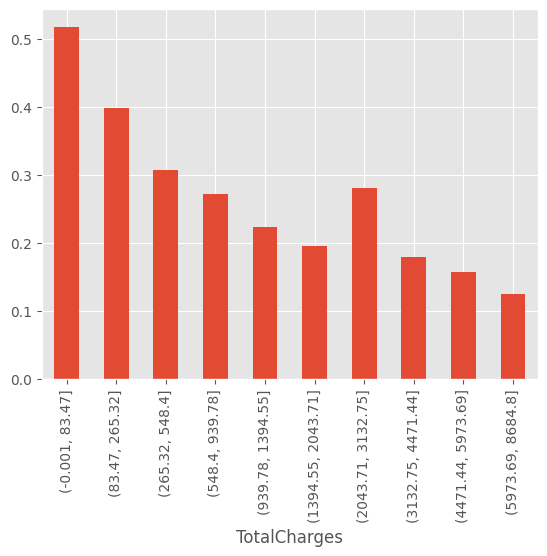

In [402]:
# TotalCharges
# -----------------------------
q_bins = 10

tc_quant_analysis = clean_df.copy()

tc_quant_analysis["TotalCharges"] = pd.qcut(
    tc_quant_analysis["TotalCharges"],
    q=q_bins
)

tc_quant_analysis_summary = (
    tc_quant_analysis.groupby("TotalCharges", observed=True)
      .agg(
          All=("Churn", "size"),
          Churned=("Churn", lambda x: (x == "Yes").sum()),
          NotChurned=("Churn", lambda x: (x == "No").sum()),
          ChurnRate=("Churn", lambda x: (x == "Yes").mean())
      )
)

tc_quant_analysis_summary["ChurnRate"].plot(kind="bar")

fig.tight_layout()
plt.show

tc_quant_analysis_summary


In [425]:
# Observations :
# Churn rate is highest for low total charges groups and would monotonically decrease as total charges increase except a single spike for a mid-high group.

# Conclusions : 
# Inital Hypothesis : Customers with high total charge may churn more often because they may be more sensitive to price or more likely to compare alternatives. 
# Data is rejecting this hypothesis as we can see that churn rate would decrease almost monotonically as total chrages increase.

,All,NotChurned,Churned,ChurnRate
Contract,,,,
Month-to-month,0.550192,0.429068,0.885500,0.427097
One year,0.209144,0.252609,0.088818,0.112695
Two year,0.240664,0.318322,0.025682,0.028319


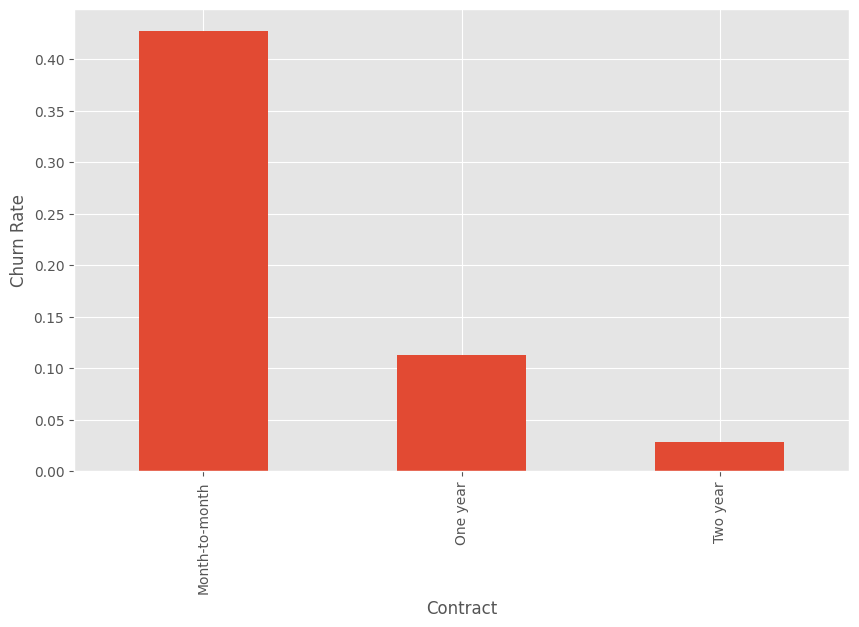

In [404]:
# Contract
# ----------------------------
# contract distribution by churn status
rows = 'Contract'
cols = 'Churn'
cols_labels = ['All', 'NotChurned', 'Churned']

cont_by_churn_df = col_by_col(clean_df, rows=rows, cols=cols, cols_labels=cols_labels)

cont_composition_df = cont_by_churn_df.div(
    cont_by_churn_df.sum(axis=0), 
    axis=1
)

churn_rate_df = churn_rate(cont_by_churn_df, 
                        plot=True)

info_table = pd.concat([cont_composition_df, churn_rate_df], axis=1)

info_table

In [405]:
# Cross checking : tenure group share by contract type 
rows = 'Contract'
cols = 'tenure'

cont_by_tenure = col_by_col(clean_df, rows=rows, cols=cols, cols_bins=tenure_bins, cols_labels=['All', *tenure_labels])
cont_by_tenure.div(cont_by_tenure['All'], axis=0) # contract type share by tenure groups


,All,0-6 Months,7-12 Months,13-24 Months,25-36 Months,37-48 Months,49-72 Months
Contract,,,,,,,
Month-to-month,1.0,0.364645,0.149935,0.190194,0.125419,0.081548,0.088258
One year,1.0,0.026477,0.057705,0.133741,0.169722,0.181942,0.430414
Two year,1.0,0.017109,0.023009,0.053097,0.056637,0.105015,0.745133


In [426]:
## Contract Notes

### Question
# Does churn rate differ by contract type?

### Hypothesis
# Month-to-month customers are expected to have higher churn rates because they have lower commitment than one-year or two-year customers.

### Evidence
# - The largest contract type is `Month-to-month`, with about 55% of customers. `One year` and `Two year` contract types represent about 20% and 24% of customers respectively.
# - About 88% of churned customers are in the `Month-to-month` contract type.
# - Churn rate decreases from about 43% for `Month-to-month` customers to about 11% for `One year` customers and about 3% for `Two year` customers.

### Conclusion
# The hypothesis is supported. `Month-to-month` customers are both higher-risk and represent the majority of churn cases, accounting for about 88% of churned customers.

### Modeling note
# `Contract` should be included as a categorical feature. The analysis suggests that `Month-to-month` contract status is especially informative, since churn rate is much higher for this group.

### Additional check: tenure composition within each contract type
# `Month-to-month` customers are concentrated in lower-tenure groups: about 36% are in the 0–6 month group, 15% are in the 7–12 month group, and 19% are in the 13–24 month group. Overall, about 70% of `Month-to-month` customers have tenure of 24 months or less.
# Longer contracts are concentrated in higher-tenure groups. About 43% of `One year` customers and about 75% of `Two year` customers are in the 49–72 month group.
# This suggests that `Contract` and `tenure` carry overlapping information. The high churn rate for `Month-to-month` customers may partly reflect the fact that many `Month-to-month` customers are also low-tenure customers.

,All,NotChurned,Churned,ChurnRate
PaymentMethod,,,,
Bank transfer (automatic),0.219225,0.248550,0.138042,0.167098
Credit card (automatic),0.216101,0.249324,0.124131,0.152431
Electronic check,0.335794,0.250097,0.573034,0.452854
Mailed check,0.228880,0.252029,0.164794,0.191067


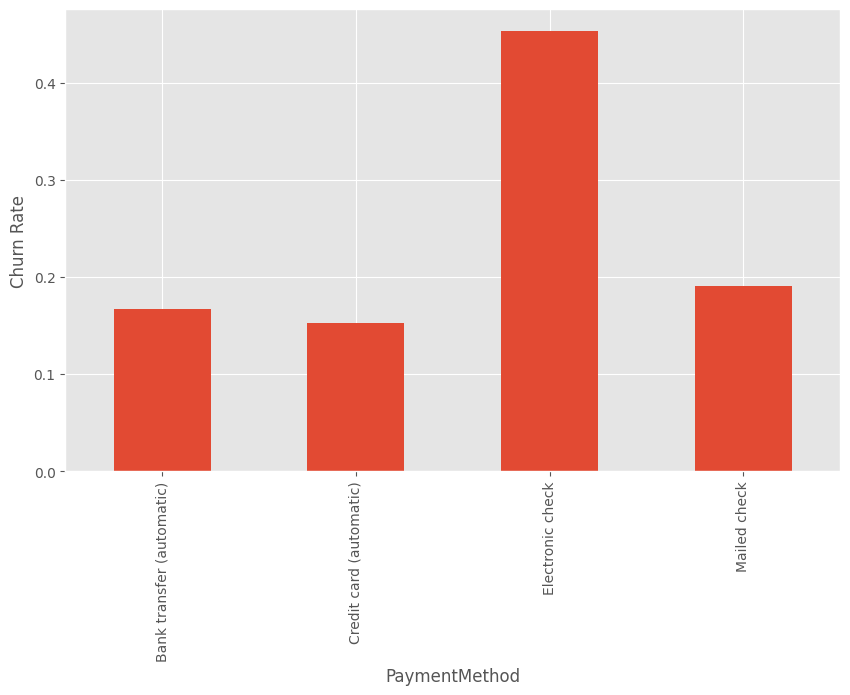

In [407]:
# PaymentMethod
# -----------------------------

# payment method distribution by churn status
rows = 'PaymentMethod'
cols = 'Churn'
cols_labels = ['All', 'NotChurned', 'Churned']

pm_by_churn_df = col_by_col(clean_df, rows=rows, cols=cols, cols_labels=cols_labels)

pm_composition_df = pm_by_churn_df.div(
    pm_by_churn_df.sum(axis=0), 
    axis=1
)


churn_rate_df = churn_rate(pm_by_churn_df, 
                        plot=True)

info_table = pd.concat([pm_composition_df, churn_rate_df], axis=1)

info_table

In [427]:
## PaymentMethod notes

### Question
# Does churn rate differ by payment method?

### Hypothesis
# Customers using non-automatic payment methods may churn more often because they may be more exposed to subscription costs and renewal decisions.

### Evidence
# - `Electronic check` is the most common payment method, representing about 34% of all customers. The other payment methods each represent roughly 22% of customers.
# - About 57% of churned customers use `Electronic check`.
# - Among non-churned customers, payment methods are more evenly distributed.
# - `Electronic check` has the highest churn rate at about 45%.
# - The other payment methods have much lower churn rates, around 15–19%.

### Conclusion
# The original hypothesis is only partially supported. Customers using `Electronic check` have a much higher churn rate, but `Mailed check`, which is also non-automatic, does not show a similarly high churn rate. Therefore, the elevated churn pattern appears specific to `Electronic check`, not to all non-automatic payment methods.


In [409]:
# Cross checking : pm share by contract type 
rows = 'PaymentMethod'
cols = 'Contract'

pm_by_cont = col_by_col(clean_df, rows=rows, cols=cols)
pm_by_cont.div(pm_by_cont.sum(axis=0), axis=1)

Contract,All,Month-to-month,One year,Two year
PaymentMethod,,,,
Bank transfer (automatic),0.219225,0.152000,0.265445,0.332743
Credit card (automatic),0.216101,0.140129,0.270197,0.342773
Electronic check,0.335794,0.477419,0.235574,0.099115
Mailed check,0.228880,0.230452,0.228785,0.225369


In [410]:
# Cross checking : pm share by tenure type 
rows = 'PaymentMethod'
cols = 'tenure'

pm_by_tenure = col_by_col(clean_df, rows=rows, cols=cols, cols_bins=tenure_bins, cols_labels=['All', *tenure_labels])
pm_by_tenure.div(pm_by_tenure.sum(axis=0), axis=1)

,All,0-6 Months,7-12 Months,13-24 Months,25-36 Months,37-48 Months,49-72 Months
PaymentMethod,,,,,,,
Bank transfer (automatic),0.219225,0.076975,0.163121,0.172852,0.218750,0.254593,0.340331
Credit card (automatic),0.216101,0.088454,0.133333,0.176758,0.225962,0.250656,0.329165
Electronic check,0.335794,0.463201,0.414184,0.371094,0.341346,0.309711,0.217508
Mailed check,0.228880,0.371371,0.289362,0.279297,0.213942,0.185039,0.112997


In [428]:
### Cross-check summary

# `Electronic check` overlaps with both `Contract` and `tenure`. It is much more common among `Month-to-month` customers and lower-tenure customers, both of which are already high-churn groups. Therefore, part of the high churn rate for `Electronic check` may reflect overlap with these features.
# However, `Mailed check` is also common among low-tenure customers but does not show a similarly high churn rate. This suggests that tenure alone does not fully explain the `Electronic check` pattern.

,All,NotChurned,Churned,ChurnRate
InternetService,,,,
DSL,0.343746,0.379204,0.245586,0.189591
Fiber optic,0.439585,0.347700,0.693954,0.418928
No,0.216669,0.273096,0.060460,0.074050


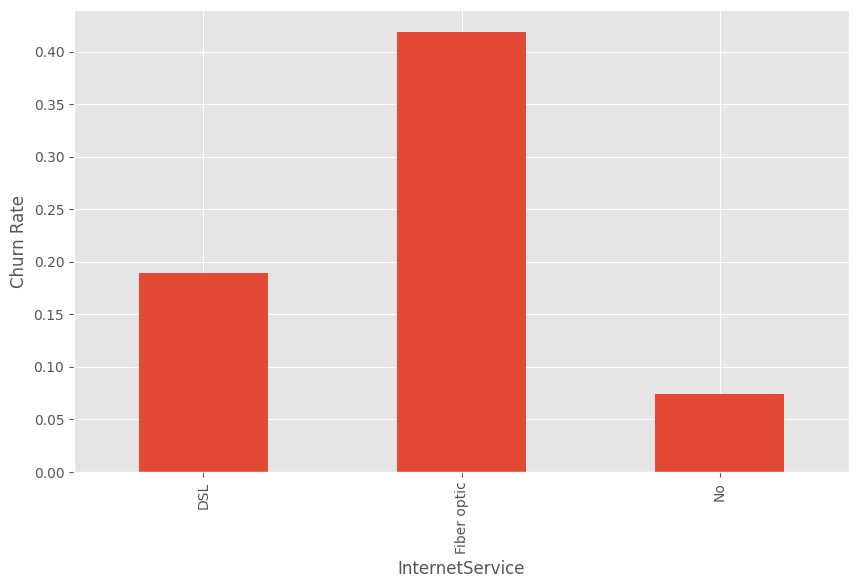

In [412]:
# InternetService
# --------------------
rows = 'InternetService'
cols = 'Churn'
cols_labels = ['All', 'NotChurned', 'Churned']

int_by_churn_df = col_by_col(clean_df, rows=rows, cols=cols, cols_labels=cols_labels)

int_composition_df = int_by_churn_df.div(
    int_by_churn_df.sum(axis=0), 
    axis=1
)


churn_rate_df = churn_rate(int_by_churn_df, 
                        plot=True)

info_table = pd.concat([int_composition_df, churn_rate_df], axis=1)

info_table


In [413]:
# Cross checking : pm share by tenure type 
rows = 'MonthlyCharges'
cols = 'InternetService'

mc_by_int = col_by_col(clean_df, rows=rows, cols=cols, rows_bins=mc_bins)
mc_by_int.div(mc_by_int.sum(axis=0), axis=1)

InternetService,All,DSL,Fiber optic,No
MonthlyCharges,,,,
"(17.25, 28.3]",0.228028,0.033044,NaN,1.0
"(28.3, 38.35]",0.027119,0.078893,NaN,NaN
"(38.35, 48.4]",0.051825,0.150764,NaN,NaN
"(48.4, 58.45]",0.090870,0.264354,NaN,NaN
"(58.45, 68.5]",0.067301,0.194548,0.000969,NaN
"(68.5, 78.55]",0.126793,0.136720,0.181525,NaN
"(78.55, 88.6]",0.135312,0.110698,0.221253,NaN
"(88.6, 98.65]",0.123953,0.030979,0.257752,NaN
"(98.65, 108.7]",0.107057,NaN,0.243540,NaN


In [429]:
## InternetService Notes

### Question
# Does churn rate differ by internet service type?

### Hypothesis
# Customers with `Fiber optic` internet may have higher churn because this service type is associated with higher monthly charges, different service expectations, or a different customer segment.

### Evidence
# - About 44% of all customers have `Fiber optic` internet, about 34% have `DSL`, and about 22% have no internet service.
# - Among churned customers, about 69% use `Fiber optic`.
# - Among non-churned customers, `DSL` and `Fiber optic` have more similar shares, while customers with no internet service represent about 27%.
# - Churn rate is highest for `Fiber optic` customers, at about 42%.
# - `DSL` customers have a lower churn rate, about 19%.
# - Customers with no internet service have the lowest churn rate, about 7%.
# - A cross-check with `MonthlyCharges` shows that `Fiber optic` customers are heavily concentrated in higher monthly charge bins, while customers with no internet service are concentrated in the lowest monthly charge bin.

### Conclusion
# The hypothesis is partially supported. `Fiber optic` customers have a much higher churn rate than `DSL` customers or customers with no internet service. However, the pattern should not be interpreted as only a price effect, because `InternetService` is strongly related to `MonthlyCharges` and likely reflects different customer/service segments.

,All,NotChurned,Churned,ChurnRate
TechSupport,,,,
No,0.629509,0.538952,0.823462,0.416355
Yes,0.370491,0.461048,0.176538,0.151663


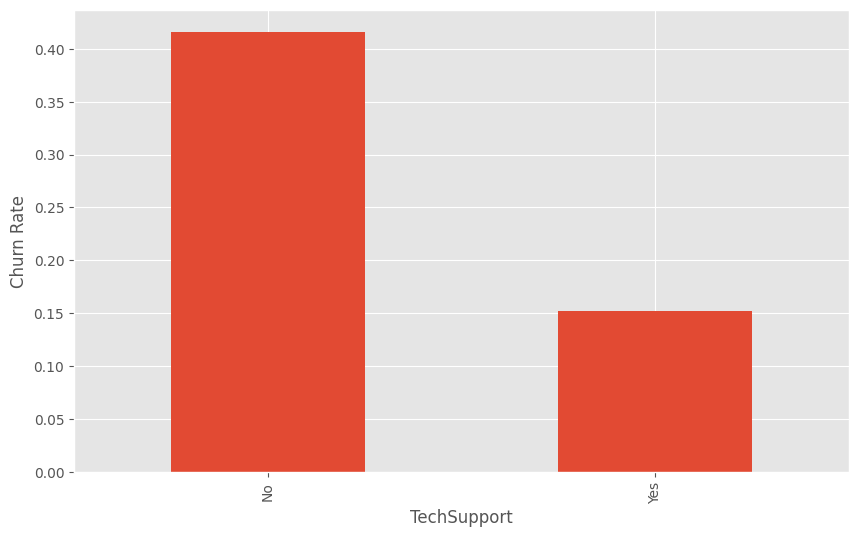

In [415]:
# TechSupport
# -----------------------------
rows = 'TechSupport'
cols = 'Churn'
cols_labels = ['All', 'NotChurned', 'Churned']

techs_by_churn_df = col_by_col(clean_df, rows=rows, cols=cols, cols_labels=cols_labels)
techs_by_churn_df.drop('No internet service', inplace=True) # redundent as InternetService was analyzed (churn rate is about 7% for non internet service)

techs_composition_df = techs_by_churn_df.div(
    techs_by_churn_df.sum(axis=0), 
    axis=1
)


churn_rate_df = churn_rate(techs_by_churn_df, 
                        plot=True)

info_table = pd.concat([techs_composition_df, churn_rate_df], axis=1)

info_table

In [430]:
## TechSupport Notes

### Question
# Are customers without TechSupport more likely to churn?

### Hypothesis
# Customers without TechSupport are expected to churn more often because unresolved technical issues may increase frustration and reduce customer satisfaction.

### Evidence
# - About 49% of all customers do not have TechSupport.
# - Among churned customers, about 77% do not have TechSupport.
# - Among non-churned customers, about 40% do not have TechSupport and about 34% do have TechSupport.
# - Churn rate is highest for customers without TechSupport, at about 41.6%.
# - Customers with TechSupport have a much lower churn rate, about 15.2%.

### Conclusion
# The hypothesis is supported. Customers without TechSupport have a substantially higher churn rate than customers with TechSupport.

In [417]:
 # Quick checckup for other entries
category_to_inspect = category_columns.copy()

for i in ['Churn', 'Contract', 'TechSupport', 'customerID', 'PaymentMethod', 'InternetService']:
    category_to_inspect.remove(i)
    
cols = 'Churn'
cols_labels = ['All', 'NotChurned', 'Churned']

for category in category_to_inspect:
    rows = category
    cat_by_churn_df = col_by_col(clean_df, rows, cols, cols_labels=cols_labels)
    cr = cat_by_churn_df['Churned'] / cat_by_churn_df['All']
    print(f"\nFor {category} churn rate is:\n")
    print(cr)


For gender churn rate is:

gender
Female    0.269209
Male      0.261603
dtype: float64

For Partner churn rate is:

Partner
No     0.329580
Yes    0.196649
dtype: float64

For Dependents churn rate is:

Dependents
No     0.312791
Yes    0.154502
dtype: float64

For PhoneService churn rate is:

PhoneService
No     0.249267
Yes    0.267096
dtype: float64

For MultipleLines churn rate is:

MultipleLines
No                  0.250442
No phone service    0.249267
Yes                 0.286099
dtype: float64

For OnlineSecurity churn rate is:

OnlineSecurity
No                     0.417667
No internet service    0.074050
Yes                    0.146112
dtype: float64

For OnlineBackup churn rate is:

OnlineBackup
No                     0.399288
No internet service    0.074050
Yes                    0.215315
dtype: float64

For DeviceProtection churn rate is:

DeviceProtection
No                     0.391276
No internet service    0.074050
Yes                    0.225021
dtype: float64

For St

In [432]:
clean_df['single'] = ~( (clean_df['Partner'] == "Yes") | (clean_df['Dependents'] == "Yes") )
clean_df['single'] = clean_df['single'].astype('str')

rows='single'
cols='Churn'
cols_labels = ['All', 'NotChurned', 'Churned']

single_by_churn_df = col_by_col(clean_df, rows, cols, cols_labels=cols_labels)
churn_rate(single_by_churn_df, plot=False)

single
False    0.198246
True     0.342378
Name: ChurnRate, dtype: float64

In [419]:
rows = 'SeniorCitizen'
cols= 'MonthlyCharges'

senior_by_mc = col_by_col(clean_df, rows=rows, cols=cols, cols_bins=mc_bins)
mc_composition_by_senior = senior_by_mc.div(senior_by_mc['All'], axis=0)
# mc_composition_by_senior.iloc[:,6:10].sum(axis=1) #72% of senior citizens have mc in 68-108 high churn risk range
# mc_composition_by_senior

sen_by_mc_composition = senior_by_mc.div(senior_by_mc.sum(axis=0), axis=1)
sen_by_mc_composition # given high churn risk ranges, senior distribution is greater for the general case.

MonthlyCharges,All,"(17.25, 28.3]","(28.3, 38.35]","(38.35, 48.4]","(48.4, 58.45]","(58.45, 68.5]","(68.5, 78.55]","(78.55, 88.6]","(88.6, 98.65]","(98.65, 108.7]","(108.7, 118.75]"
SeniorCitizen,,,,,,,,,,,
0,0.837853,0.958904,0.853403,0.854795,0.907813,0.909283,0.778275,0.79958,0.737686,0.724138,0.772109
1,0.162147,0.041096,0.146597,0.145205,0.092188,0.090717,0.221725,0.20042,0.262314,0.275862,0.227891


In [420]:
rows = 'SeniorCitizen'
cols= 'tenure'

sen_by_tenure_df = col_by_col(clean_df, rows=rows, cols=cols, cols_bins=tenure_bins, cols_labels=['All', *tenure_labels])
ten_composition_by_senior = sen_by_tenure_df.div(sen_by_tenure_df['All'], axis=0)
ten_composition_by_senior # tenure dist given senior is same as general dist

sen_by_ten_composition = sen_by_tenure_df.div(sen_by_tenure_df.sum(axis=0), axis=1)
sen_by_ten_composition # senior dist given tenure is same as general dist

,All,0-6 Months,7-12 Months,13-24 Months,25-36 Months,37-48 Months,49-72 Months
SeniorCitizen,,,,,,,
0,0.837853,0.853477,0.853901,0.835938,0.810096,0.838583,0.833408
1,0.162147,0.146523,0.146099,0.164062,0.189904,0.161417,0.166592


In [421]:
rows = 'SeniorCitizen'
cols= 'PaymentMethod'

sen_by_pm_df = col_by_col(clean_df, rows=rows, cols=cols)
pm_composition_by_senior = sen_by_pm_df.div(sen_by_pm_df['All'], axis=0)
pm_composition_by_senior # pm dist given senior=0 similar to general dist. but, when senior=1 the dist is similar to the dist seen in the churn population when examening payment method.

# sen_by_ten_composition = sen_by_tenure_df.div(sen_by_tenure_df.sum(axis=0), axis=1)
# sen_by_ten_composition # senior dist given tenure is same as general dist

PaymentMethod,All,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
SeniorCitizen,,,,,
0,1.0,0.222166,0.220471,0.300119,0.257245
1,1.0,0.204028,0.193520,0.520140,0.082312


In [422]:
rows = 'PaperlessBilling'
cols= 'SeniorCitizen'

pb_by_senior_df = col_by_col(clean_df, rows=rows, cols=cols)
pb_by_senior_df.div(pb_by_senior_df.sum(axis=0), axis=1)
# pb_composition_by_senior = sen_by_pb_df.div(sen_by_pb_df['All'], axis=0)
# pb_composition_by_senior # paperless billing dist given senior=0 similar to general dist. but, when senior=1 the dist is similar to the dist seen in the churn population.

# sen_by_ten_composition = sen_by_tenure_df.div(sen_by_tenure_df.sum(axis=0), axis=1)
# sen_by_ten_composition # senior dist given tenure is same as general dist

SeniorCitizen,All,0,1
PaperlessBilling,,,
No,0.407781,0.44162,0.232925
Yes,0.592219,0.55838,0.767075


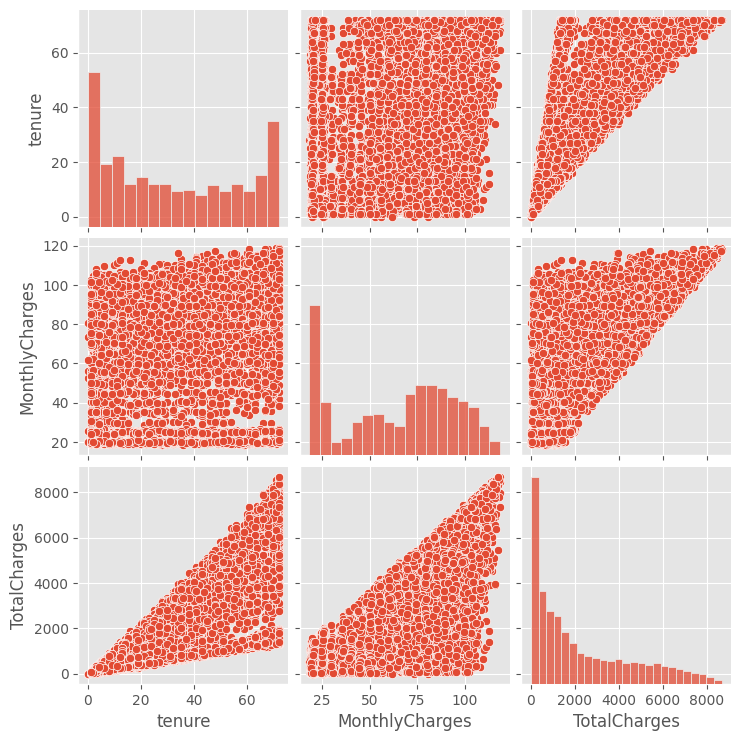

In [423]:
# Correlation check for tenure MC, TC and TC=MC*tenure approximation

sns.pairplot(clean_df,
             vars=['tenure', 'MonthlyCharges', 'TotalCharges'],
            )

fig.tight_layout()
plt.show()

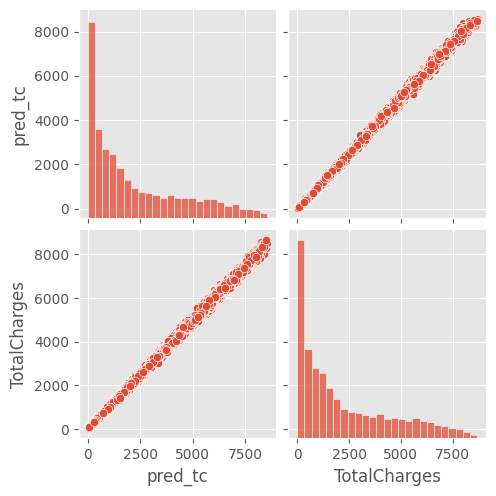

,pred_tc,TotalCharges,tenure,MonthlyCharges
pred_tc,1.000000,0.999561,0.826568,0.651566
TotalCharges,0.999561,1.000000,0.826178,0.651174
tenure,0.826568,0.826178,1.000000,0.247900
MonthlyCharges,0.651566,0.651174,0.247900,1.000000


In [424]:
mult = clean_df.copy()
mult['pred_tc'] = mult['tenure'] * mult['MonthlyCharges']

sns.pairplot(mult,
             vars=['pred_tc', 'TotalCharges'],
            )

fig.tight_layout()
plt.show()

mult[["pred_tc", "TotalCharges", "tenure", "MonthlyCharges"]].corr()